In [ ]:
import nd2
import matplotlib.pyplot as plt
import hvplot.xarray
import hvplot
import panel as pn
import numpy as np
import xarray as xr
import dask
import dask.array as da
from dask.distributed import Client, LocalCluster
from dask import delayed
from typing import List
from pystackreg import StackReg
cluster = LocalCluster(
    processes=True,       
    threads_per_worker=1, 
    n_workers=10,          
    memory_limit='20GB'   
)
cluster.adapt(minimum=1, maximum=32)
client = Client(cluster)
hvplot.extension('bokeh')

client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 10
Total threads: 10,Total memory: 186.26 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37553,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:45897,Total threads: 1
Dashboard: http://127.0.0.1:42669/status,Memory: 18.63 GiB
Nanny: tcp://127.0.0.1:46123,


2025-12-05 14:07:13,097 - tornado.application - ERROR - Uncaught exception GET /status/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='127.0.0.1:8787', method='GET', uri='/status/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/home/georgeos/GitHub/PyMMM/.pixi/envs/default/lib/python3.13/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
  File "/home/georgeos/GitHub/PyMMM/.pixi/envs/default/lib/python3.13/site-packages/tornado/web.py", line 3375, in wrapper
    return method(self, *args, **kwargs)
  File "/home/georgeos/GitHub/PyMMM/.pixi/envs/default/lib/python3.13/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app with a larger value for --session-token-expiration if necessary")
bokeh.protocol.exceptions.ProtocolError: Token is expired. Configure the app with a larger value 

In [75]:
def add_identity_frame_multi_fov(matrices: xr.DataArray, original_ref: xr.DataArray) -> xr.DataArray:
    """
    Prepends identity matrices to the stack, handling (T, P, row, col) or (T, row, col).
    """
    # 1. Identify non-matrix dimensions (e.g., P) excluding T, row, col
    non_matrix_dims = [d for d in matrices.dims if d not in {'T', 'row', 'col'}]
    
    # 2. Create the identity block (1, 3, 3)
    eye_data = np.eye(3)[None, :, :]
    
    # 3. If there are extra dims (like P), we must broadcast the identity matrix
    if non_matrix_dims:
        # Get shape of the extra dimensions from the input matrices
        extra_shape = tuple(matrices.sizes[d] for d in non_matrix_dims)
        # Reshape to (1, P, ..., 3, 3)
        expand_shape = (1,) + extra_shape + (3, 3)
        # Broadcast 
        eye_data = np.broadcast_to(eye_data, expand_shape)

    # 4. Create DataArray
    # Construct coords for the first timepoint
    first_t_coord = original_ref.coords['T'].isel(T=[0])
    
    # Coordinates for P (and others) must match the input matrices
    coords = {d: matrices.coords[d] for d in non_matrix_dims}
    coords['T'] = first_t_coord

    identity_da = xr.DataArray(
        eye_data, 
        dims=['T'] + non_matrix_dims + ['row', 'col'],
        coords=coords
    )
    
    # 5. Concatenate
    full_stack = xr.concat([identity_da, matrices], dim='T')
    full_stack['T'] = original_ref.coords['T']
    
    return full_stack

def get_cumulative_matrices_vectorized(matrices_da: xr.DataArray) -> xr.DataArray:
    """
    Computes cumulative matrix product along T, preserving P dimension.
    """
    # Pull to memory
    mats_np = matrices_da.compute().values
    
    # Initialize output
    cumulative = np.zeros_like(mats_np)
    
    # Determine axis indices for standard matrix multiplication
    # Assumes dims are (T, P, row, col) or (T, row, col)
    # The last two dimensions are always row, col (3, 3)
    
    # Set T=0
    cumulative[0] = mats_np[0]
    
    # Iterate T
    # NumPy @ operator broadcasts over the P dimension automatically
    for t in range(1, len(mats_np)):
        cumulative[t] = cumulative[t-1] @ mats_np[t]
        
    return xr.DataArray(
        cumulative,
        dims=matrices_da.dims,
        coords=matrices_da.coords
    )

def get_lazy_matrix(ref_da: xr.DataArray, mov_da: xr.DataArray) -> xr.DataArray:
    """
    Lazily computes the transformation matrix between two DataArrays.
    """
    return xr.apply_ufunc(
        _register_and_get_matrix,
        ref_da,
        mov_da,
        input_core_dims=[['Y', 'X'], ['Y', 'X']],  # Assuming nd2 uses uppercase Y, X
        output_core_dims=[['row', 'col']],         # The output is a 3x3 matrix
        vectorize=False,                            # Vectorise over non-core dims if present
        dask='allowed',                       # Enable Dask handling
        output_dtypes=[np.float64],
        dask_gufunc_kwargs={'output_sizes': {'row': 3, 'col': 3}},
        keep_attrs=False #drop the nd2 metadata
    )

def _register_and_get_matrix(ref: np.ndarray, mov: np.ndarray) -> np.ndarray:
    """
    Worker function to register two images and extract the transformation matrix.
    
    This function instantiates StackReg locally to ensure thread safety 
    across Dask workers.
    """
    # Ensure inputs are 2D arrays (handle potential extra singleton dims)
    ref_sq = np.squeeze(ref)
    mov_sq = np.squeeze(mov)
    
    assert ref_sq.ndim == 2, "Reference image must be 2D"
    assert mov_sq.ndim == 2, "Moving image must be 2D"
    sr = StackReg(StackReg.RIGID_BODY)
    sr.register(ref_sq, mov_sq)
    return sr.get_matrix()

In [2]:
experiment_nd2 = nd2.imread("/data/20251127_SB1_M9-0.05_24hrsOld_1hrAmpicillin_differentConcs.nd2", dask=True, xarray=True)

In [69]:
ref_stack = experiment_nd2.isel(T=slice(0, -1))
mov_stack = experiment_nd2.isel(T=slice(1, None))
mov_stack['T'] = ref_stack['T']

In [77]:
relative_matrices_lazy = xr.apply_ufunc(
    _register_and_get_matrix,
    ref_stack,
    mov_stack,
    input_core_dims=[['Y', 'X'], ['Y', 'X']],
    output_core_dims=[['row', 'col']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[np.float64],
    dask_gufunc_kwargs={'output_sizes': {'row': 3, 'col': 3}},
    keep_attrs=False
)

relative_matrices_with_identity = add_identity_frame_multi_fov(
    relative_matrices_lazy, 
    experiment_nd2
)

In [ ]:
relative_matrices_with_identity = relative_matrices_with_identity.compute()

In [ ]:
absolute_matrices = get_cumulative_matrices_vectorized(relative_matrices_with_identity)

In [ ]:
stabilized_experiment = xr.apply_ufunc(
    _warp_frame,
    experiment_nd2,
    absolute_matrices,
    input_core_dims=[['Y', 'X'], ['row', 'col']],
    output_core_dims=[['Y', 'X']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[experiment_nd2.dtype],
    dask_gufunc_kwargs={
        'output_sizes': {
            'Y': experiment_nd2.sizes['Y'], 
            'X': experiment_nd2.sizes['X']
        }
    },
    keep_attrs=True
)

# 5. Output
# stabilized_experiment is now a lazy dask array of the same shape as input
# (T, P, Y, X), but stabilized.
stabilized_experiment

In [7]:
FOV = FOV.chunk({"T": 1}) # no need, the T chunk is already 1
ref_stack = FOV.isel(T=slice(0, -1))
mov_stack = FOV.isel(T=slice(1, None))
mov_stack['T'] = ref_stack['T']

In [45]:
relative_matrices = xr.apply_ufunc(
        _register_and_get_matrix,
        ref_stack,
        mov_stack,
        input_core_dims=[['Y', 'X'], ['Y', 'X']],
        output_core_dims=[['row', 'col']],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[np.float64],
        dask_gufunc_kwargs={'output_sizes': {'row': 3, 'col': 3}},
        keep_attrs=False
    )
# Execute
relative_matrices = add_identity_frame(relative_matrices, FOV)

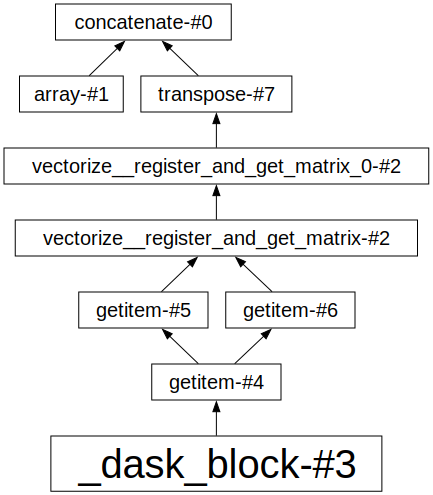

In [46]:
relative_matrices.data.dask.visualize()

In [ ]:
relative_matrices_comp = relative_matrices.compute()

2025-12-05 14:27:47,014 - distributed.core - INFO - Connection to tcp://127.0.0.1:37553 has been closed.
2025-12-05 14:27:47,020 - distributed.core - INFO - Connection to tcp://127.0.0.1:37553 has been closed.
2025-12-05 14:27:47,025 - distributed.core - INFO - Connection to tcp://127.0.0.1:37553 has been closed.
2025-12-05 14:27:47,854 - distributed.core - INFO - Connection to tcp://127.0.0.1:37553 has been closed.
2025-12-05 14:27:47,859 - distributed.core - INFO - Connection to tcp://127.0.0.1:37553 has been closed.
2025-12-05 14:27:48,855 - distributed.core - INFO - Connection to tcp://127.0.0.1:37553 has been closed.
2025-12-05 14:27:49,857 - distributed.core - INFO - Connection to tcp://127.0.0.1:37553 has been closed.
2025-12-05 14:27:49,857 - distributed.core - INFO - Connection to tcp://127.0.0.1:37553 has been closed.
2025-12-05 14:27:49,863 - distributed.core - INFO - Connection to tcp://127.0.0.1:37553 has been closed.
2025-12-05 14:27:49,863 - distributed.core - INFO - Con

2025-12-05 14:27:50,031 - distributed.core - INFO - Connection to tcp://127.0.0.1:37553 has been closed.


In [ ]:
absolute_matrices = get_cumulative_matrices(relative_matrices_comp)

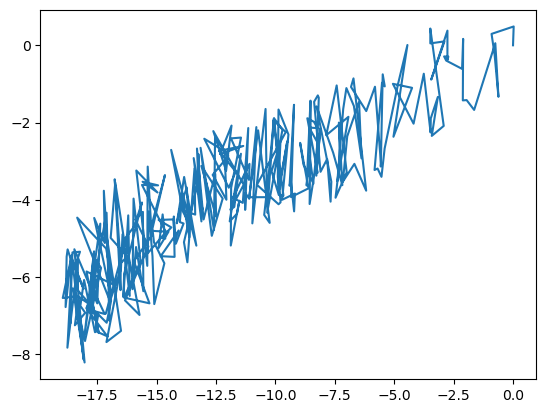

In [52]:
plt.plot(absolute_matrices[:,0,2], absolute_matrices[:,1,2])

In [ ]:
from skimage.transform import warp

def _warp_frame(image: np.ndarray, matrix: np.ndarray) -> np.ndarray:
    """
    Worker function to warp a single 2D image using a 3x3 matrix.
    """
    # dont invert the matrix, pystackreg already does it
    
    return warp(
        image, 
        matrix, 
        preserve_range=True, # Keep original intensity values
        order=3              # Bicubic interpolation (slower but better quality)
    )

def apply_stabilization(fov_stack: xr.DataArray, matrices: xr.DataArray) -> xr.DataArray:
    """
    Applies transformation matrices to an image stack in parallel.
    """
    return xr.apply_ufunc(
        _warp_frame,
        fov_stack,
        matrices,
        input_core_dims=[['Y', 'X'], ['row', 'col']], # Image is 2D, Matrix is 3x3
        output_core_dims=[['Y', 'X']],                # Output is 2D image
        vectorize=True,                               # Vectorize loop over T
        dask='parallelized',                          # Enable parallel Dask execution
        output_dtypes=[fov_stack.dtype],              # Preserve original dtype
        dask_gufunc_kwargs={'output_sizes': {'Y': fov_stack.sizes['Y'], 'X': fov_stack.sizes['X']}},
        keep_attrs=True                               # Keep metadata
    )

# Execute lazy computation
stabilized_FOV: xr.DataArray = apply_stabilization(FOV, absolute_matrices)


In [66]:
stabilized_FOV_comp = stabilized_FOV.compute()

In [67]:
stabilized_FOV_comp.hvplot.image(x="X", y="Y", cmap="Greys_r", dynamic=True, rasterize=True, framewise=False, widget_location="top", aspect='equal')

BokehModel(combine_events=True, render_bundle={'docs_json': {'823dfbf7-565c-43fb-bb99-e8d028e0ed0e': {'version…

In [64]:
FOV.hvplot.image(x="X", y="Y", cmap="Greys_r", dynamic=True, rasterize=True, framewise=False, widget_location="top", aspect='equal')

BokehModel(combine_events=True, render_bundle={'docs_json': {'846d1dc0-791c-4e84-9821-ee4a50004a67': {'version…